import json
from pathlib import Path

RESULT_PATH = Path('bbox_results.json')  # adjust if needed
assert RESULT_PATH.exists(), f"Not found: {RESULT_PATH}"

with RESULT_PATH.open('r', encoding='utf-8') as f:
    records = json.load(f)

print(f"Loaded {len(records)} items from {RESULT_PATH}")
records[44]  # show the first record structure

Random not-full bbox idx: 17503
text: Replace the blurry face depicted on the large background screen with a dynamic, high-resolution image of a nebula, maintaining the existing stage lighting and ensuring the nebula's vibrant colors blend naturally with the overall event atmosphere.
edit_type: Replace one object category with another


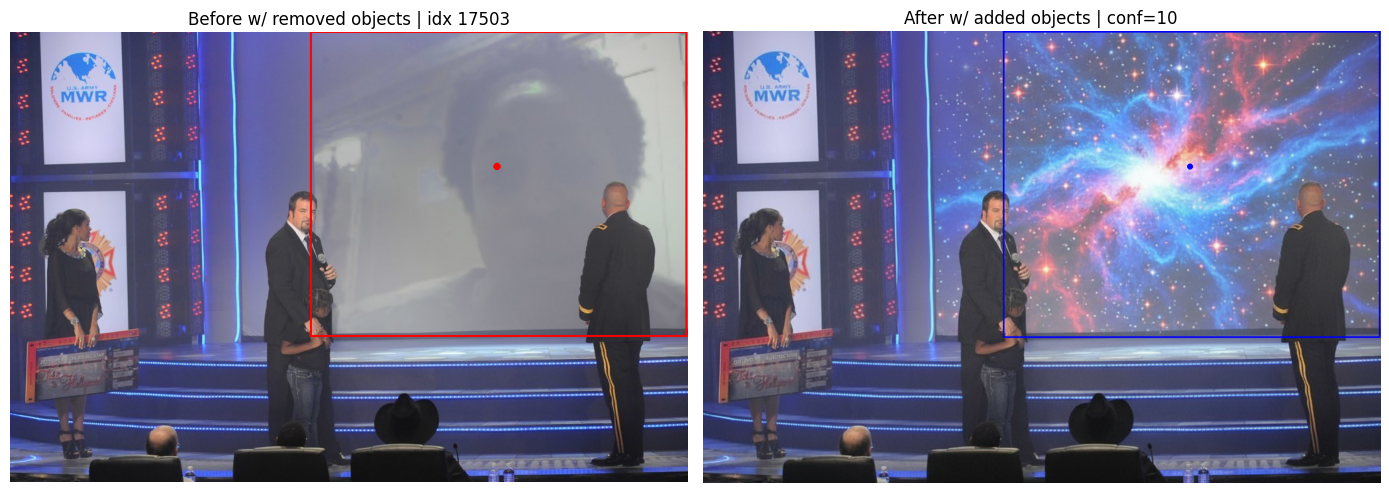

  Object 0 (removed): removed blurry face on background screen
  Object 1 (added): new dynamic nebula image on background screen
Random not-full bbox idx: 19479
text: Remove the two white paper labels with text ('JAHODOVÝ KOKTEJL' and 'BANÁNOVÝ KOKTEJL') from the front of the counter, seamlessly reconstructing the underlying light grey/beige patterned counter surface to match its existing texture and color, while preserving the overall lighting and composition of the scene.
edit_type: Remove an existing object


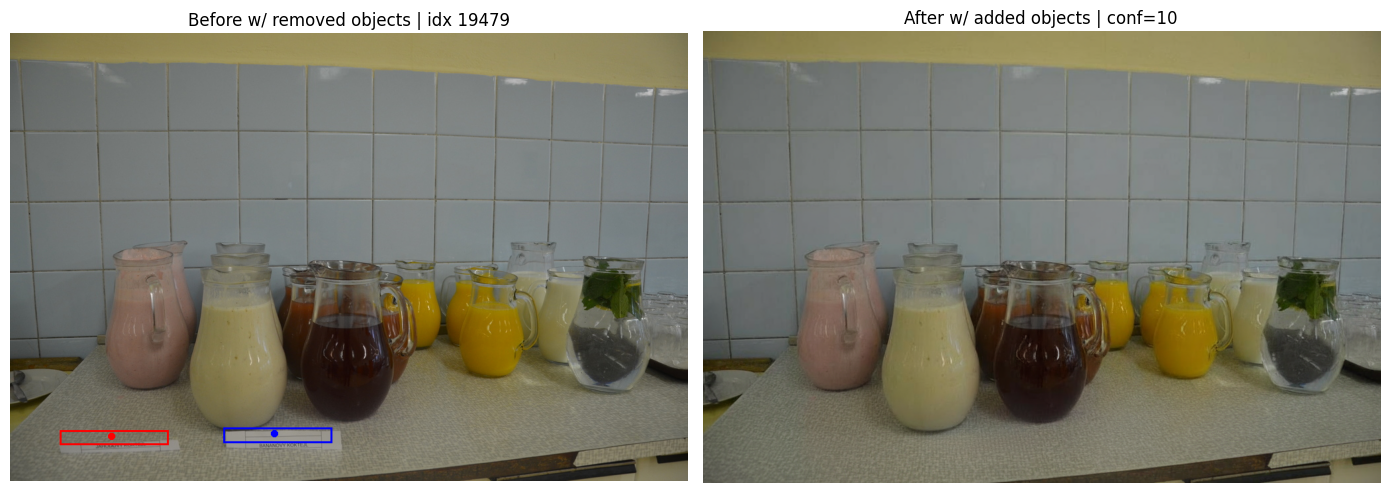

  Object 0 (removed): removed white paper label with text 'JAHODOVÝ KOKTEJL'
  Object 1 (removed): removed white paper label with text 'BANÁNOVÝ KOKTEJL'


In [ ]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import random
import pandas as pd


def _bbox_to_pixels(coords, w, h):
    """Support normalized [0-1], 0-1000 scale, or absolute pixel coords."""
    if not coords or len(coords) != 4:
        return None
    max_c = max(coords)
    if max_c <= 1.5:
        norm = coords  # already normalized
    elif max_c <= 1000:
        norm = [c / 1000.0 for c in coords]  # 0-1000 grid
    else:
        left, top, right, bottom = coords
        return (
            int(max(0, min(left, w))),
            int(max(0, min(top, h))),
            int(max(0, min(right, w))),
            int(max(0, min(bottom, h))),
        )

    left, top, right, bottom = [
        int(norm[0] * w),
        int(norm[1] * h),
        int(norm[2] * w),
        int(norm[3] * h),
    ]
    return (
        int(max(0, min(left, w))),
        int(max(0, min(top, h))),
        int(max(0, min(right, w))),
        int(max(0, min(bottom, h))),
    )


def _build_df_from_records():
    rows = []
    for i, item in enumerate(records):
        bbox = item.get('bbox') or {}
        # 新格式: objects 数组, 旧格式: bbox_normalized (0-1) 或其他
        objects = bbox.get('objects')
        if objects and isinstance(objects, list) and len(objects) > 0:
            # 使用第一个 object 的 bbox
            bbox_coords = objects[0].get('bbox')
            num_objects = len(objects)
        else:
            # 兼容旧格式
            bbox_coords = bbox.get('bbox') or bbox.get('bbox_normalized') or bbox.get('after_bbox_normalized') or bbox.get('change_bbox_normalized')
            num_objects = 1 if bbox_coords else 0
        
        rows.append({
            'idx': i,
            'before_image': item.get('local_input_image') or item.get('before_image'),
            'after_image': item.get('output_image') or item.get('after_image'),
            'bbox_norm': bbox_coords,
            'bbox_raw': bbox.get('change_bbox'),
            'confidence': bbox.get('confidence'),
            'text': item.get('text'),
            'edit_type': item.get('edit_type'),
            'num_objects': num_objects,
        })
    return pd.DataFrame(rows)


def _ensure_not_full_subset():
    if 'df' in globals():
        df_local = df.copy()
    else:
        df_local = _build_df_from_records()
    def _area_ratio_local(coords):
        if not coords or len(coords) != 4:
            return None
        m = max(coords)
        if m <= 1.5:
            norm = coords
        elif m <= 1000:
            norm = [c / 1000.0 for c in coords]
        else:
            return None
        l, t, r, b = norm
        return max(0.0, r - l) * max(0.0, b - t)
    
    # Calculate bbox area ratio
    if 'bbox_area_ratio' not in df_local.columns:
        df_local['bbox_area_ratio'] = df_local['bbox_norm'].apply(_area_ratio_local)
    
    subset = df_local[(df_local['bbox_area_ratio'].notnull()) & (df_local['bbox_area_ratio'] < 0.95)]
    if subset.empty:
        return None
    return subset


def show_bbox(idx: int):
    """显示指定索引的 before/after 图片，并根据 is_remove 在对应图片上绘制 bbox 和中心点"""
    item = records[idx]
    bbox_info = item.get('bbox') or {}
    
    # 获取所有 objects
    objects = bbox_info.get('objects')
    if not objects or not isinstance(objects, list):
        # 兼容旧格式
        coords = bbox_info.get('bbox') or bbox_info.get('bbox_normalized') or bbox_info.get('after_bbox_normalized') or bbox_info.get('change_bbox_normalized') or bbox_info.get('change_bbox')
        region_point = bbox_info.get('region_point') or bbox_info.get('after_region_point')
        if coords:
            objects = [{'bbox': coords, 'region_point': region_point, 'description': '', 'is_remove': False}]
        else:
            print(f"idx {idx}: no bbox")
            return

    before_path = item.get('local_input_image') or item.get('before_image')
    after_path = item.get('output_image') or item.get('after_image')
    
    if not before_path or not after_path:
        print(f"idx {idx}: missing image paths")
        return

    before_img = Image.open(before_path).convert('RGB')
    after_img = Image.open(after_path).convert('RGB')
    
    before_w, before_h = before_img.size
    after_w, after_h = after_img.size
    
    before_drawn = before_img.copy()
    after_drawn = after_img.copy()
    draw_before = ImageDraw.Draw(before_drawn)
    draw_after = ImageDraw.Draw(after_drawn)
    
    colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'cyan', 'magenta']
    
    # 根据 is_remove 决定在哪张图上画 bbox
    for obj_idx, obj in enumerate(objects):
        coords = obj.get('bbox')
        region_point = obj.get('region_point')
        is_remove = obj.get('is_remove', False)
        
        if not coords:
            continue
        
        color = colors[obj_idx % len(colors)]
        
        # is_remove=True: 在 before 图上画; is_remove=False: 在 after 图上画
        if is_remove:
            # 在 before 图上绘制
            bbox_pixels = _bbox_to_pixels(coords, before_w, before_h)
            if bbox_pixels:
                draw_before.rectangle(bbox_pixels, outline=color, width=3)
                
                # 绘制中心点
                if region_point:
                    if max(region_point) > 1.5:
                        center_x = (region_point[0] / 1000.0) * before_w
                        center_y = (region_point[1] / 1000.0) * before_h
                    else:
                        center_x = region_point[0] * before_w
                        center_y = region_point[1] * before_h
                    draw_before.ellipse([center_x-5, center_y-5, center_x+5, center_y+5], fill=color, outline=color)
        else:
            # 在 after 图上绘制
            bbox_pixels = _bbox_to_pixels(coords, after_w, after_h)
            if bbox_pixels:
                draw_after.rectangle(bbox_pixels, outline=color, width=3)
                
                # 绘制中心点
                if region_point:
                    if max(region_point) > 1.5:
                        center_x = (region_point[0] / 1000.0) * after_w
                        center_y = (region_point[1] / 1000.0) * after_h
                    else:
                        center_x = region_point[0] * after_w
                        center_y = region_point[1] * after_h
                    draw_after.ellipse([center_x-5, center_y-5, center_x+5, center_y+5], fill=color, outline=color)

    plt.figure(figsize=(14, 7))
    plt.subplot(1, 2, 1)
    plt.imshow(before_drawn)
    plt.title(f'Before w/ removed objects | idx {idx}')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(after_drawn)
    plt.title(f"After w/ added objects | conf={bbox_info.get('confidence')}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # 打印每个 object 的描述
    for obj_idx, obj in enumerate(objects):
        desc = obj.get('description', '')
        is_remove = obj.get('is_remove', False)
        if desc:
            print(f"  Object {obj_idx} ({'removed' if is_remove else 'added'}): {desc}")


def show_random_not_full():
    subset = _ensure_not_full_subset()
    if subset is None or subset.empty:
        print('No bbox under 95% area found; showing random sample instead.')
        idx = random.randint(0, len(records) - 1)
    else:
        idx = int(subset.sample(1)['idx'].iloc[0])
        print(f'Random not-full bbox idx: {idx}')
        if 'text' in subset.columns:
            row = subset.loc[subset['idx'] == idx]
            if not row.empty:
                text_val = row['text'].iloc[0]
                print('text:', text_val)
                edit_type_val = row['edit_type'].iloc[0]
                print('edit_type:', edit_type_val)
    show_bbox(idx)

# Example: randomly visualize a bbox that does NOT cover the whole image

show_random_not_full()
show_random_not_full()


In [2]:
# SAM2 setup (run once)
from transformers import Sam2Processor, Sam2Model
import torch
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

sam_model = Sam2Model.from_pretrained("facebook/sam2.1-hiera-large").to(device)
sam_processor = Sam2Processor.from_pretrained("facebook/sam2.1-hiera-large")

print("SAM2 model loaded successfully!")

Using device: cuda


You are using a model of type sam2_video to instantiate a model of type sam2. This is not supported for all configurations of models and can yield errors.


SAM2 model loaded successfully!


In [3]:
# 使用 SAM2 生成 mask (支持多个 bbox 批量输入，根据 is_remove 选择图片)
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

def generate_mask_from_bbox(idx: int, visualize=True):
    """
    为指定索引的记录生成 masks
    根据 is_remove 决定使用哪张图片:
    - is_remove=True: 使用 before 图 (local_input_image)
    - is_remove=False: 使用 after 图 (output_image)
    将同类 objects 批量输入给 SAM2
    返回所有 masks 和对应的 IoU 分数
    """
    item = records[idx]
    bbox_info = item.get('bbox') or {}
    edit_type = item.get('edit_type', '')
    
    # 获取所有 objects
    objects = bbox_info.get('objects')
    if not objects or not isinstance(objects, list):
        # 兼容旧格式
        coords = bbox_info.get('bbox') or bbox_info.get('bbox_normalized') or bbox_info.get('after_bbox_normalized') or bbox_info.get('change_bbox_normalized') or bbox_info.get('change_bbox')
        region_point = bbox_info.get('region_point') or bbox_info.get('after_region_point')
        if coords:
            objects = [{'bbox': coords, 'region_point': region_point, 'description': '', 'is_remove': False}]
        else:
            print(f"idx {idx}: 没有 bbox 信息")
            return None
    
    print(f"Processing sample (Edit type: {edit_type})")
    print(f"Found {len(objects)} object(s)")
    
    # 分组: removed objects 和 added objects
    removed_objects = [obj for obj in objects if obj.get('is_remove', False)]
    added_objects = [obj for obj in objects if not obj.get('is_remove', False)]
    
    before_path = item.get('local_input_image') or item.get('before_image')
    after_path = item.get('output_image') or item.get('after_image')
    
    all_results = []
    
    # 处理 removed objects (在 before 图上)
    if removed_objects and before_path:
        print(f"\nProcessing {len(removed_objects)} removed object(s) on BEFORE image")
        before_results = _process_objects_on_image(
            removed_objects, before_path, idx, 'removed'
        )
        if before_results:
            all_results.extend(before_results)
    
    # 处理 added objects (在 after 图上)
    if added_objects and after_path:
        print(f"\nProcessing {len(added_objects)} added object(s) on AFTER image")
        after_results = _process_objects_on_image(
            added_objects, after_path, idx, 'added'
        )
        if after_results:
            all_results.extend(after_results)
    
    if not all_results:
        print(f"idx {idx}: 没有生成任何 mask")
        return None
    
    if visualize:
        _visualize_results(item, all_results, idx, bbox_info)
    
    return {
        'idx': idx,
        'results': all_results,
        'num_objects': len(all_results),
        'avg_iou': np.mean([r['iou_score'] for r in all_results]),
    }


def _process_objects_on_image(objects, img_path, idx, obj_type):
    """在指定图片上处理一组 objects"""
    # 加载图片
    img = Image.open(img_path).convert('RGB')
    w, h = img.size
    
    # 准备批量输入
    all_boxes = []
    all_points = []
    all_labels = []
    all_descriptions = []
    
    for obj_idx, obj in enumerate(objects):
        coords = obj.get('bbox')
        region_point = obj.get('region_point')
        description = obj.get('description', '')
        
        if not coords:
            print(f"  Object {obj_idx}: 跳过 (没有 bbox)")
            continue
        
        # 转换 bbox 到像素坐标
        bbox_pixels = _bbox_to_pixels(coords, w, h)
        if not bbox_pixels:
            print(f"  Object {obj_idx}: bbox 转换失败")
            continue
        
        left, top, right, bottom = bbox_pixels
        all_boxes.append([left, top, right, bottom])
        
        # 转换中心点到像素坐标
        if region_point:
            if max(region_point) > 1.5:
                center_x = (region_point[0] / 1000.0) * w
                center_y = (region_point[1] / 1000.0) * h
            else:
                center_x = region_point[0] * w
                center_y = region_point[1] * h
            all_points.append([[center_x, center_y]])
            all_labels.append([1])
        else:
            # 如果没有 region_point，使用 bbox 中心
            center_x = (left + right) / 2
            center_y = (top + bottom) / 2
            all_points.append([[center_x, center_y]])
            all_labels.append([1])
        
        all_descriptions.append(description)
        print(f"  Object {obj_idx}: bbox={coords}, point={region_point}, desc={description}")
    
    if not all_boxes:
        print(f"  没有有效的 bbox")
        return None
    
    # 准备 SAM2 输入
    input_points = [all_points]
    input_labels = [all_labels]
    input_boxes = [all_boxes]
    
    print(f"  SAM2 输入: {len(all_boxes)} boxes, {len(all_points)} points")
    
    # 使用 SAM2 processor
    inputs = sam_processor(
        images=img,
        # input_points=input_points,
        # input_labels=input_labels,
        input_boxes=input_boxes,
        return_tensors='pt'
    )
    
    # 移动到设备
    for k, v in inputs.items():
        if isinstance(v, torch.Tensor):
            inputs[k] = v.to(device)
    
    # 推理
    with torch.no_grad():
        outputs = sam_model(**inputs)
    
    # 获取 masks 和 IoU 分数
    pred_masks = outputs.pred_masks.cpu()
    iou_scores = outputs.iou_scores.cpu().numpy()
    
    print(f"  pred_masks shape: {pred_masks.shape}")
    print(f"  iou_scores shape: {iou_scores.shape}")
    
    # 后处理 masks 到原始图像尺寸
    masks = sam_processor.post_process_masks(
        pred_masks, 
        inputs["original_sizes"]
    )[0]
    
    print(f"  Post-processed masks shape: {masks.shape}")
    
    # 为每个 object 选择最佳 mask
    results = []
    num_objects = masks.shape[0]
    
    for obj_idx in range(num_objects):
        obj_masks = masks[obj_idx]
        obj_iou_scores = iou_scores[0, obj_idx]
        
        # 选择 IoU 最高的 mask
        best_mask_idx = np.argmax(obj_iou_scores)
        best_mask = obj_masks[best_mask_idx].numpy() > 0
        best_iou = obj_iou_scores[best_mask_idx]
        
        results.append({
            'object_idx': obj_idx,
            'mask': best_mask,
            'iou_score': best_iou,
            'all_iou_scores': obj_iou_scores.tolist(),
            'bbox_pixels': all_boxes[obj_idx],
            'center_point': (all_points[obj_idx][0][0], all_points[obj_idx][0][1]),
            'description': all_descriptions[obj_idx],
            'obj_type': obj_type,  # 'removed' 或 'added'
            'image_path': img_path,
            'image_size': (w, h)
        })
        
        print(f"  Object {obj_idx}: 最佳 IoU = {best_iou:.4f}, 所有 IoU = {obj_iou_scores.tolist()}")
    
    return results


def _visualize_results(item, all_results, idx, bbox_info):
    """可视化结果: before, after, masks"""
    before_path = item.get('local_input_image') or item.get('before_image')
    after_path = item.get('output_image') or item.get('after_image')
    
    # 分组结果
    removed_results = [r for r in all_results if r['obj_type'] == 'removed']
    added_results = [r for r in all_results if r['obj_type'] == 'added']
    
    # 决定显示多少列
    num_cols = 2  # before, after
    if removed_results:
        num_cols += 1  # removed masks
    if added_results:
        num_cols += 1  # added masks
    
    fig, axes = plt.subplots(1, num_cols, figsize=(6*num_cols, 6))
    if num_cols == 1:
        axes = [axes]
    
    col_idx = 0
    colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'cyan', 'magenta']
    
    # Before 图片 + removed bbox
    if before_path:
        before_img = Image.open(before_path).convert('RGB')
        before_w, before_h = before_img.size
        before_drawn = before_img.copy()
        draw = ImageDraw.Draw(before_drawn)
        
        for obj_idx, result in enumerate(removed_results):
            color = colors[obj_idx % len(colors)]
            bbox_px = result['bbox_pixels']
            center_pt = result['center_point']
            
            draw.rectangle(bbox_px, outline=color, width=3)
            draw.ellipse([center_pt[0]-5, center_pt[1]-5, center_pt[0]+5, center_pt[1]+5], fill=color, outline=color)
        
        axes[col_idx].imshow(before_drawn)
        axes[col_idx].set_title(f'Before + {len(removed_results)} Removed BBoxes (idx {idx})')
        axes[col_idx].axis('off')
        col_idx += 1
    
    # After 图片 + added bbox
    if after_path:
        after_img = Image.open(after_path).convert('RGB')
        after_w, after_h = after_img.size
        after_drawn = after_img.copy()
        draw = ImageDraw.Draw(after_drawn)
        
        for obj_idx, result in enumerate(added_results):
            color = colors[obj_idx % len(colors)]
            bbox_px = result['bbox_pixels']
            center_pt = result['center_point']
            
            draw.rectangle(bbox_px, outline=color, width=3)
            draw.ellipse([center_pt[0]-5, center_pt[1]-5, center_pt[0]+5, center_pt[1]+5], fill=color, outline=color)
        
        axes[col_idx].imshow(after_drawn)
        axes[col_idx].set_title(f'After + {len(added_results)} Added BBoxes')
        axes[col_idx].axis('off')
        col_idx += 1
    
    colors_rgba = [
        [1, 0, 0, 0.4],    # 红色
        [0, 0, 1, 0.4],    # 蓝色
        [0, 1, 0, 0.4],    # 绿色
        [1, 1, 0, 0.4],    # 黄色
        [1, 0, 1, 0.4],    # 紫色
        [1, 0.5, 0, 0.4],  # 橙色
        [0, 1, 1, 0.4],    # 青色
        [1, 0, 0.5, 0.4],  # 品红
    ]
    
    # Removed Masks
    if removed_results and before_path:
        before_img = Image.open(before_path).convert('RGB')
        axes[col_idx].imshow(before_img)
        
        for obj_idx, result in enumerate(removed_results):
            mask = result['mask']
            color = colors_rgba[obj_idx % len(colors_rgba)]
            
            mask_overlay = np.zeros((*mask.shape, 4))
            mask_overlay[mask > 0] = color
            axes[col_idx].imshow(mask_overlay)
        
        avg_iou = np.mean([r['iou_score'] for r in removed_results])
        axes[col_idx].set_title(f'{len(removed_results)} Removed Masks (Avg IoU={avg_iou:.4f})')
        axes[col_idx].axis('off')
        col_idx += 1
    
    # Added Masks
    if added_results and after_path:
        after_img = Image.open(after_path).convert('RGB')
        axes[col_idx].imshow(after_img)
        
        for obj_idx, result in enumerate(added_results):
            mask = result['mask']
            color = colors_rgba[obj_idx % len(colors_rgba)]
            
            mask_overlay = np.zeros((*mask.shape, 4))
            mask_overlay[mask > 0] = color
            axes[col_idx].imshow(mask_overlay)
        
        avg_iou = np.mean([r['iou_score'] for r in added_results])
        axes[col_idx].set_title(f'{len(added_results)} Added Masks (Avg IoU={avg_iou:.4f})')
        axes[col_idx].axis('off')
        col_idx += 1
    
    plt.tight_layout()
    plt.show()
    
    # 打印详细信息
    print(f"\n详细信息:")
    print(f"Edit type: {item.get('edit_type')}")
    print(f"Text: {item.get('text')}")
    print(f"BBox Confidence: {bbox_info.get('confidence')}")
    
    if removed_results:
        print(f"\nRemoved objects:")
        for result in removed_results:
            print(f"  Object {result['object_idx']}: {result['description']}, IoU={result['iou_score']:.4f}")
    
    if added_results:
        print(f"\nAdded objects:")
        for result in added_results:
            print(f"  Object {result['object_idx']}: {result['description']}, IoU={result['iou_score']:.4f}")


# 测试: 为前5个样本生成 masks
k = 2576
for i in range(k, k+5):
    print(f"\n{'='*80}")
    print(f"Processing sample {i}")
    print('='*80)
    result = generate_mask_from_bbox(i, visualize=True)



Processing sample 2576
Processing sample (Edit type: Add a new object to the scene)
Found 1 object(s)

Processing 1 added object(s) on AFTER image


NameError: name '_bbox_to_pixels' is not defined

Processing sample (Edit type: Replace one object category with another)
Found 22 object(s)

Processing 20 removed object(s) on BEFORE image
  Object 0: bbox=[107, 0, 757, 998], point=[450, 450], desc=removed large anime body pillow featuring a character in a green and white outfit
  Object 1: bbox=[725, 139, 937, 735], point=[800, 450], desc=removed anime body pillow featuring an orange-haired character in an orange outfit
  Object 2: bbox=[0, 114, 136, 603], point=[50, 350], desc=removed hanging anime merchandise on the left
  Object 3: bbox=[0, 590, 217, 800], point=[100, 700], desc=removed boxes of anime merchandise on the lower left
  Object 4: bbox=[757, 850, 999, 998], point=[850, 920], desc=removed plush toys and anime merchandise on the lower right
  Object 5: bbox=[772, 700, 949, 810], point=[850, 750], desc=removed plush toy on the right shelf
  Object 6: bbox=[937, 680, 999, 850], point=[960, 750], desc=removed white plush toy on the right
  Object 7: bbox=[282, 820, 500, 96

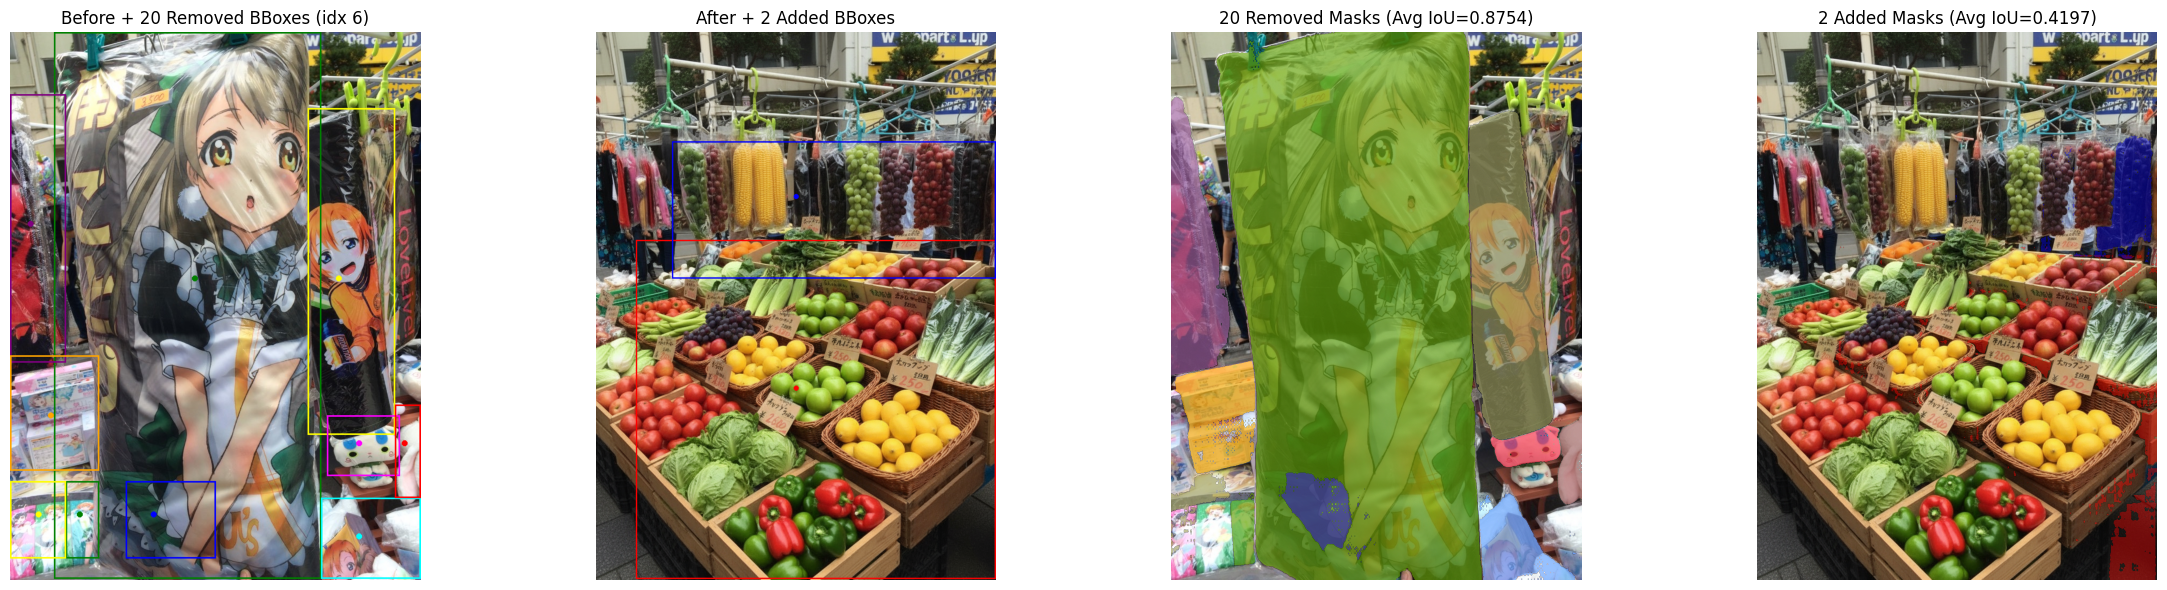


详细信息:
Edit type: Replace one object category with another
Text: Replace all hanging anime body pillows and related merchandise with a vibrant array of freshly picked, brightly colored seasonal fruits and vegetables, such as ripe red tomatoes, leafy green lettuce, and golden yellow corn, arranged artfully in rustic wooden crates and woven baskets, showcasing their fresh, crisp textures under the existing natural outdoor market lighting, and update any visible price tags to reflect new, appropriate values.
BBox Confidence: 9

Removed objects:
  Object 0: removed large anime body pillow featuring a character in a green and white outfit, IoU=0.9911
  Object 1: removed anime body pillow featuring an orange-haired character in an orange outfit, IoU=0.9820
  Object 2: removed hanging anime merchandise on the left, IoU=0.9479
  Object 3: removed boxes of anime merchandise on the lower left, IoU=0.9270
  Object 4: removed plush toys and anime merchandise on the lower right, IoU=0.9037
  Object

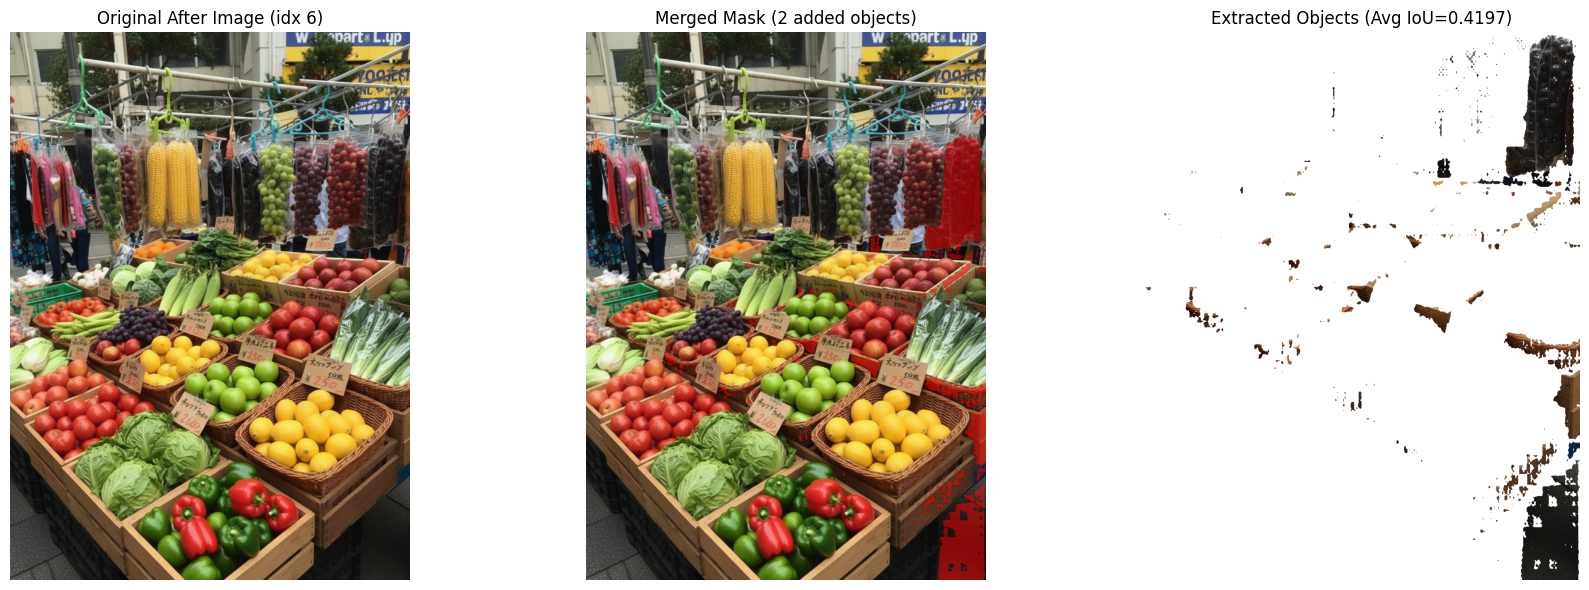

Processing sample (Edit type: Replace one object category with another)
Found 22 object(s)

Processing 20 removed object(s) on BEFORE image
  Object 0: bbox=[107, 0, 757, 998], point=[450, 450], desc=removed large anime body pillow featuring a character in a green and white outfit
  Object 1: bbox=[725, 139, 937, 735], point=[800, 450], desc=removed anime body pillow featuring an orange-haired character in an orange outfit
  Object 2: bbox=[0, 114, 136, 603], point=[50, 350], desc=removed hanging anime merchandise on the left
  Object 3: bbox=[0, 590, 217, 800], point=[100, 700], desc=removed boxes of anime merchandise on the lower left
  Object 4: bbox=[757, 850, 999, 998], point=[850, 920], desc=removed plush toys and anime merchandise on the lower right
  Object 5: bbox=[772, 700, 949, 810], point=[850, 750], desc=removed plush toy on the right shelf
  Object 6: bbox=[937, 680, 999, 850], point=[960, 750], desc=removed white plush toy on the right
  Object 7: bbox=[282, 820, 500, 96

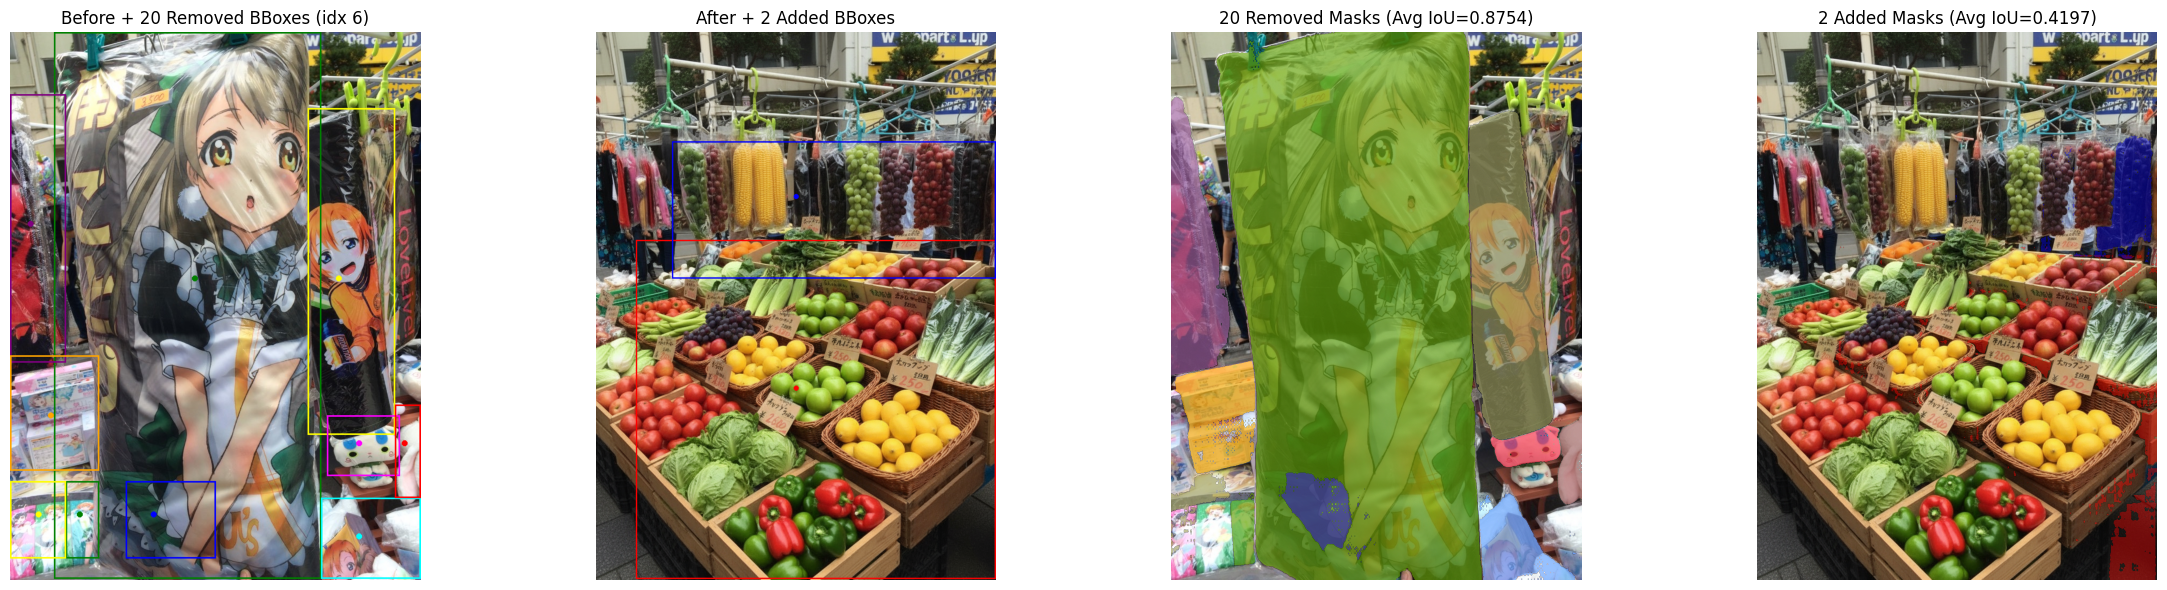


详细信息:
Edit type: Replace one object category with another
Text: Replace all hanging anime body pillows and related merchandise with a vibrant array of freshly picked, brightly colored seasonal fruits and vegetables, such as ripe red tomatoes, leafy green lettuce, and golden yellow corn, arranged artfully in rustic wooden crates and woven baskets, showcasing their fresh, crisp textures under the existing natural outdoor market lighting, and update any visible price tags to reflect new, appropriate values.
BBox Confidence: 9

Removed objects:
  Object 0: removed large anime body pillow featuring a character in a green and white outfit, IoU=0.9911
  Object 1: removed anime body pillow featuring an orange-haired character in an orange outfit, IoU=0.9820
  Object 2: removed hanging anime merchandise on the left, IoU=0.9479
  Object 3: removed boxes of anime merchandise on the lower left, IoU=0.9270
  Object 4: removed plush toys and anime merchandise on the lower right, IoU=0.9037
  Object

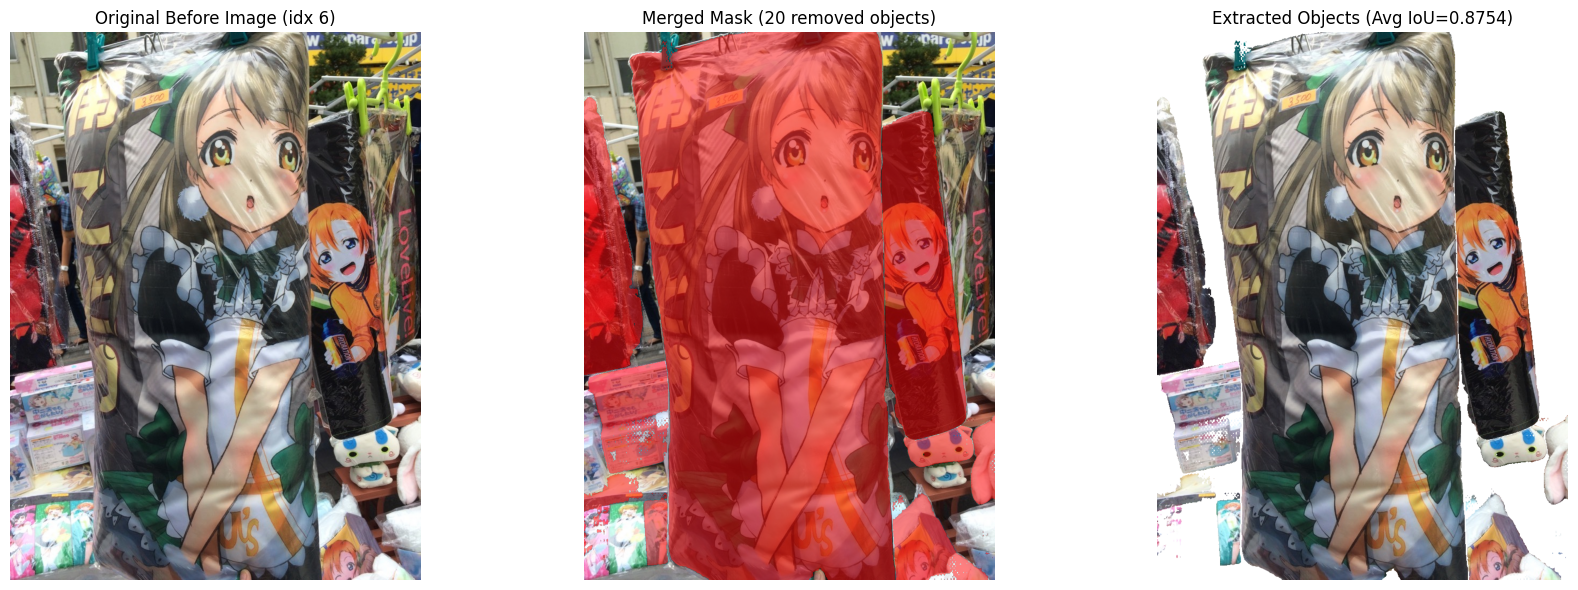

In [6]:
def extract_objects_from_after_image(idx: int, save_dir='extracted_objects', extract_removed=False):
    """
    从图片中抠出物体
    - extract_removed=False: 从 after 图中抠出 added objects (默认)
    - extract_removed=True: 从 before 图中抠出 removed objects
    将多个 mask 合并成一个统一的 mask,然后提取物体并保存为 PNG 文件
    """
    from pathlib import Path
    
    # 生成 mask
    result = generate_mask_from_bbox(idx, visualize=True)
    
    if not result:
        print(f"idx {idx}: 无法生成 mask")
        return None
    
    # 创建保存目录
    save_path = Path(save_dir)
    save_path.mkdir(exist_ok=True)
    
    # 根据 extract_removed 选择要提取的 objects
    if extract_removed:
        target_results = [r for r in result['results'] if r['obj_type'] == 'removed']
        obj_type_name = 'removed'
    else:
        target_results = [r for r in result['results'] if r['obj_type'] == 'added']
        obj_type_name = 'added'
    
    if not target_results:
        print(f"idx {idx}: 没有 {obj_type_name} objects")
        return None
    
    # 获取图片路径和尺寸
    img_path = target_results[0]['image_path']
    img = Image.open(img_path).convert('RGB')
    img_array = np.array(img)
    h, w = img_array.shape[:2]
    
    # 合并所有 masks
    merged_mask = np.zeros((h, w), dtype=bool)
    all_descriptions = []
    all_iou_scores = []
    
    print(f"\n合并 {len(target_results)} 个 {obj_type_name} mask:")
    for result_item in target_results:
        mask = result_item['mask']
        description = result_item['description']
        iou_score = result_item['iou_score']
        
        # 将当前 mask 合并到总 mask 中 (使用逻辑或)
        merged_mask = merged_mask | mask
        all_descriptions.append(description)
        all_iou_scores.append(iou_score)
        
        print(f"  Object {result_item['object_idx']}: {description} (IoU={iou_score:.4f})")
    
    # 使用合并后的 mask 创建白色背景图像
    extracted = np.full((h, w, 3), 255, dtype=np.uint8)  # 白色背景，RGB
    extracted[merged_mask] = img_array[merged_mask]  # 复制RGB到mask区域
    
    # 计算合并后 mask 的边界框(用于裁剪)
    mask_coords = np.argwhere(merged_mask)
    if len(mask_coords) > 0:
        top, left = mask_coords.min(axis=0)
        bottom, right = mask_coords.max(axis=0)
        # 添加一些 padding
        padding = 5
        top = max(0, top - padding)
        left = max(0, left - padding)
        bottom = min(h, bottom + padding + 1)
        right = min(w, right + padding + 1)
        
        cropped = extracted[top:bottom, left:right]
    else:
        cropped = extracted
    
    # 保存合并后的结果
    avg_iou = np.mean(all_iou_scores)
    desc_clean = '_'.join([d.replace(' ', '_').replace('/', '_')[:20] for d in all_descriptions if d])
    if not desc_clean:
        desc_clean = 'merged_objects'
    filename = f"idx{idx}_{obj_type_name}_{desc_clean[:80]}_iou{avg_iou:.3f}.png"
    save_file = save_path / filename
    
    Image.fromarray(cropped).save(save_file)
    print(f"\n已保存合并结果: {save_file}")
    print(f"  合并了 {len(target_results)} 个 {obj_type_name} 物体")
    print(f"  平均 IoU: {avg_iou:.4f}")
    print(f"  裁剪区域: [{left}:{right}, {top}:{bottom}]")
    
    # 可视化合并后的 mask
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 原始图片
    axes[0].imshow(img)
    axes[0].set_title(f'Original {"Before" if extract_removed else "After"} Image (idx {idx})')
    axes[0].axis('off')
    
    # 合并后的 mask 覆盖层
    axes[1].imshow(img)
    mask_overlay = np.zeros((h, w, 4))
    mask_overlay[merged_mask] = [1, 0, 0, 0.5]  # 红色半透明
    axes[1].imshow(mask_overlay)
    axes[1].set_title(f'Merged Mask ({len(target_results)} {obj_type_name} objects)')
    axes[1].axis('off')
    
    # 抠出的物体(裁剪后)
    axes[2].imshow(cropped)
    axes[2].set_title(f'Extracted Objects (Avg IoU={avg_iou:.4f})')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'idx': idx,
        'num_objects': len(target_results),
        'avg_iou': avg_iou,
        'save_path': str(save_file),
        'merged_mask': merged_mask,
        'descriptions': all_descriptions,
        'bbox_cropped': (left, top, right, bottom),
        'obj_type': obj_type_name,
    }


# 测试: 从样本中提取物体
# 提取 added objects (默认)
extracted = extract_objects_from_after_image(6, extract_removed=False)

# 如果要提取 removed objects，使用:
extracted = extract_objects_from_after_image(6, extract_removed=True)